## Implementing Gradient Descent for simple linear regression

implementing univariate linear regression using Gradient Descent and comparing it with sklearn on univarite dataset

In [172]:
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,root_mean_squared_error

In [173]:
x,y=make_regression(n_samples=500,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

In [174]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

using Sklearn implementation to compare our implementation

In [175]:
lr=LinearRegression()
lr.fit(X_test,y_test)

LinearRegression()

In [176]:
y_pred_sklearn=lr.predict(X_test)

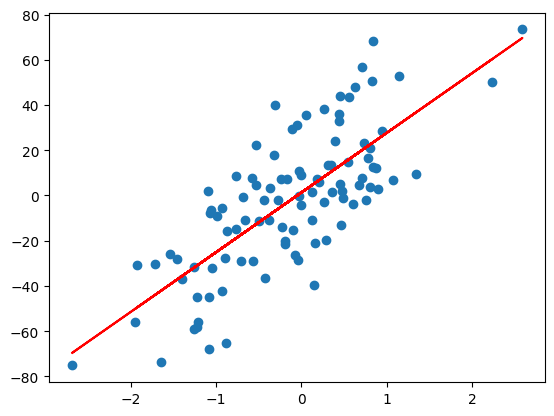

In [177]:
plt.scatter(X_test,y_test)
plt.plot(X_test,lr.predict(X_test),color='red')

In [178]:
m=lr.coef_
lr.coef_

array([26.38926304])

In [179]:
lr.intercept_

1.2440823682086641

### Gradient Descent Regressor for single linear regression (case of two features only)
1. INITIALIZE
   - m  ← 100        (arbitrary starting slope)
   - b  ← -120       (arbitrary starting intercept)
   - lr ← learning_rate
   - epochs ← number of iterations

2. FOR each epoch in range(epochs):

   a. Compute residuals:
      error = y - (m * X) - b

   b. Compute gradient w.r.t b:
      ∂L/∂b = -2 * Σ(error)

   c. Compute gradient w.r.t m:
      ∂L/∂m = -2 * Σ(error * X)

   d. Update parameters simultaneously:
      b ← b - lr * (∂L/∂b)
      m ← m - lr * (∂L/∂m)

3. OUTPUT final m and b


In [180]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
        
    def predict(self,X):
        return self.m * X + self.b

In [181]:
Mylr=GDRegressor(0.0001,1000)
Mylr.fit(X_test,y_test)

26.389266243716314 1.2440839983989649


In [182]:
y_pred_GDR= Mylr.predict(X_test)

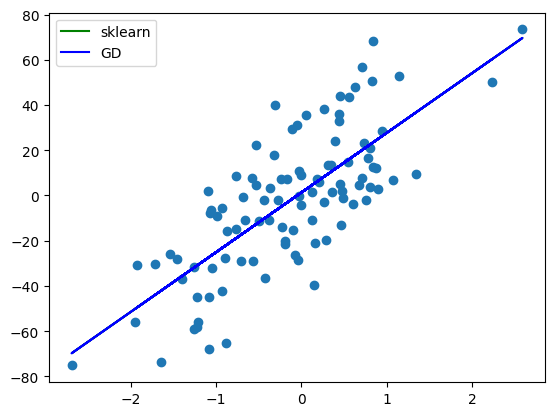

In [194]:
plt.scatter(X_test,y_test)
plt.plot(X_test,lr.predict(X_test),color='green',label='sklearn')
plt.plot(X_test,Mylr.predict(X_test),color='blue',label='GD')
plt.legend()

Both the lines overalap 
## Conclusion 
our implementation is working well in univariate cases

checking regression metrices and comparing with sklearn (visually we know that our lines are literally the same still just cross verifying)

In [184]:
from sklearn.metrics import r2_score

In [185]:
print(f"R2_score for sklearn : {r2_score(y_test,y_pred_sklearn)}\nR2_score for our implementation : {r2_score(y_test,y_pred_GDR)}")

R2_score for sklearn : 0.5656912804716598
R2_score for our implementation : 0.56569128047165


In [186]:
print(f"rmse for sklearn : {root_mean_squared_error(y_test,y_pred_sklearn)}\nrmse for our implementation : {root_mean_squared_error(y_test,y_pred_GDR)}")

rmse for sklearn : 20.473316545233352
rmse for our implementation : 20.47331654523358


## Limitation of current implementation 
 we can only evaluate and express y as a fuction of just independent variable and not more than that
